In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']    
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['models']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'   
SHOWMODELS = [
    'baseline_nonlocal_vertical',
    'kernel_nonparametric_vertical',
    'kernel_mixparametric_vertical']

In [4]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truepr = ds.pr.load()

timeseries = truepr.mean(dim=('lat','lon'))
q05 = timeseries.quantile(0.05).item()
q45 = timeseries.quantile(0.45).item()
q55 = timeseries.quantile(0.55).item()
q95 = timeseries.quantile(0.95).item()
regimes = {
    'dry':timeseries<=q05,
    'typical':(timeseries>=q45)&(timeseries<=q55),
    'wet':timeseries>=q95}

results = []
for model in CONFIGS['models']:
    name,desc = model['name'],model['description']
    if name not in SHOWMODELS:
        continue
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    with xr.open_dataset(filepath,engine='h5netcdf') as ds:
        predpr = ds.pr.load()
    ytrue,ypred = xr.align(truepr,predpr,join='inner')
    ypred  = ypred.mean('seed')
    regime = {}
    for name,mask in regimes.items():
        regime[name] = {
            'true':ytrue.sel(time=mask).mean('time'),
            'pred':ypred.sel(time=mask).mean('time')}
    results.append((desc,regime))

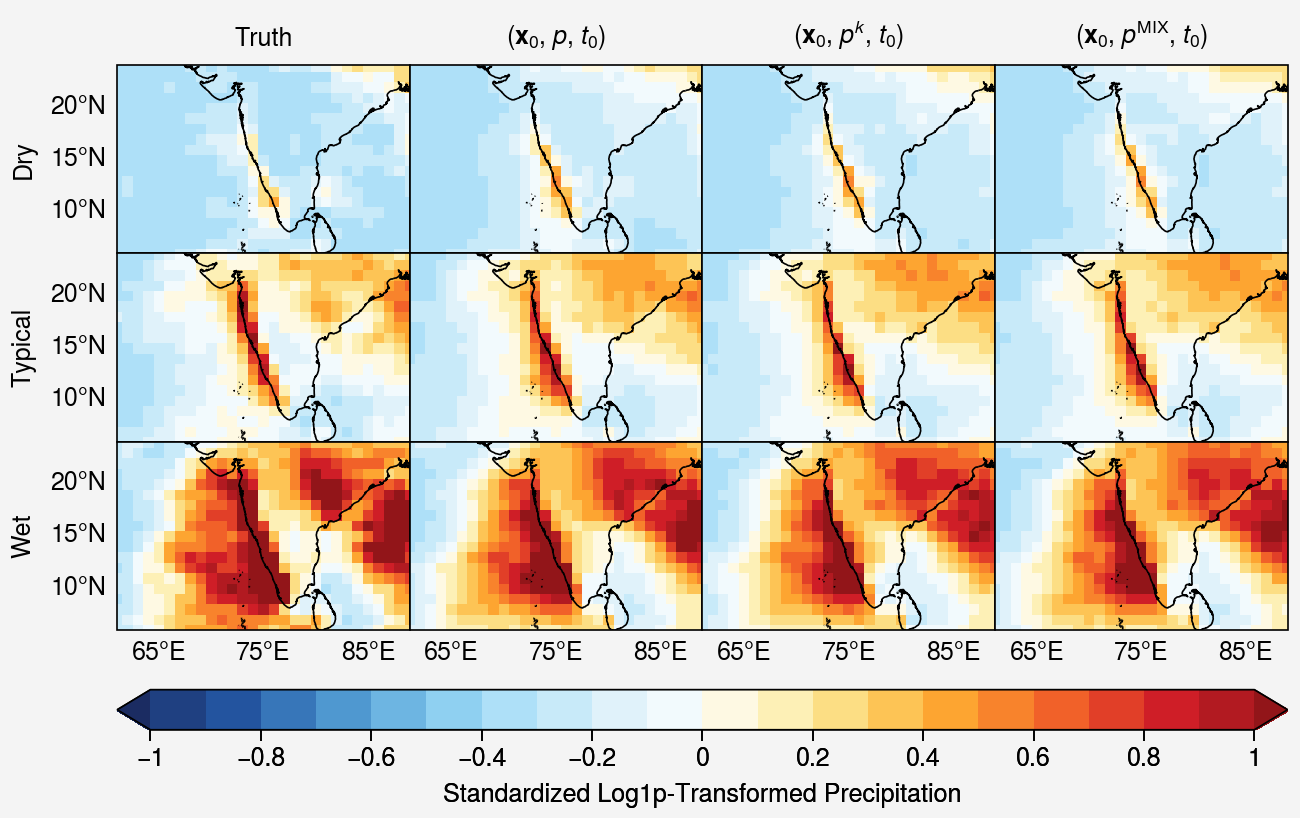

In [5]:
fig,axs = pplt.subplots(nrows=3,ncols=len(results)+1,proj='cyl',figwidth=6.5,space=0,tight=True,share=True)
axs.format(grid=False,rowlabels=['Dry','Typical','Wet'],collabels=['Truth']+[r[0] for r in results],
           latlim=(LATRANGE[0]+1,LATRANGE[1]-1),lonlim=(LONRANGE[0]+1,LONRANGE[1]-1),coast=True)
axs[:,0].format(latlabels='l',latlines=[10,15,20])
axs[-1,:].format(lonlabels='b',lonlines=[65,75,85])
style = dict(cmap='ColdHot',vmin=-1,vmax=1,levels=20,extend='both')
im = axs[0,0].pcolormesh(results[0][1]['dry']['true'],**style)
axs[1,0].pcolormesh(results[0][1]['typical']['true'],**style)
axs[2,0].pcolormesh(results[0][1]['wet']['true'],**style)
for j,(desc,regime) in enumerate(results,start=1):
    axs[0,j].pcolormesh(regime['dry']['pred'],**style)
    axs[1,j].pcolormesh(regime['typical']['pred'],**style)
    axs[2,j].pcolormesh(regime['wet']['pred'],**style)

fig.colorbar(im,loc='b',label='Standardized Log1p-Transformed Precipitation')
pplt.show()
fig.save('../figs/fig_S1.jpg')